# Chapter 4: Linear Models of Returns

In [73]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Data Prep and Generic Strategy

In [2]:
data_path = os.path.join(os.getcwd(), "data")

In [3]:
path = os.path.join(data_path, "RawPX.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .loc[lambda x: x.Price == "Adj Close"]
    .dropna())

In [4]:
tickers = (df_raw
    [["date", "Ticker"]]
    .groupby("Ticker")
    .agg("min")
    .sort_values("date")
    .assign(year = lambda x: x.date.dt.year)
    .loc[lambda x: x.year <= 2005]
    .index
    .to_list())

In [5]:
df_rtn = (df_raw
    .loc[lambda x: x.Ticker.isin(tickers)]
    .set_index("date")
    .drop(columns = ["Price"])
    .groupby("Ticker")
    .apply(lambda x: x.value.pct_change())
    .reset_index())

In [6]:
alpha_renamer = {
    'alpha_weight': r"$\alpha$ Weight", 
    'perp_weight' : r"$\alpha_{\perp}$ Weight"}

renamer = {**alpha_renamer}

## 4.3 Alpha Spanned and Alpha Orthogonal

Start with using SPY and QQQ as the factors and the sector ETFs as the
individual securities. First start by running $n$ regressions for $n$ securities:
$$
r_t = \alpha + \beta f_t+ \varepsilon_t
$$
Then with the vector of $\mathbf{\alpha} \in \mathbb{R}^n$ and the matrix of loadings $\mathbf{B} \in \mathbb{R}^{n \times 2}$ (for SPY and QQQ factor), we can introduce in the idea of $\mathbf{\alpha}_{\perp}$ and $\mathbf{\alpha}_{\parallel}$ via
$$
\mathbf{\alpha} = \mathbf{\alpha}_{\perp} + \mathbf{B}\lambda 
$$
The $\lambda$ is the projection but for computational feasability it can be solved via the least squares
$$
\mathbb{\hat\lambda} = \arg\min_{\lambda \in \mathbb{R}^K} \|\mathbf{\alpha - B\lambda}\|^2
$$
Then plug in $\lambda$ with some indeterminacy 
$$
\mathbf{r_t} = \mathbf{\alpha_{\perp}} + \mathbf{B}\left( \mathbf{\lambda} + \mathbb{E}(f_t)\right) + \mathbf{B}\left(f_t - \mathbb{E}(f_t)\right)
$$

In [7]:
df_longer = (df_rtn
    .pivot(index = "date", columns = "Ticker", values = "value")
    .drop(columns = ["IYY"])
    .reset_index()
    .melt(id_vars = ["date", "SPY", "QQQ"])
    .dropna())

In [8]:
tickers = df_longer.Ticker.drop_duplicates().sort_values().to_list()

In [30]:
factors = ["SPY", "QQQ"]

alphas, betas, resids = [], [], []
for ticker in tickers:
    
    df_tmp = (df_longer
        .loc[lambda x: x.Ticker == ticker]
        .set_index("date"))
    
    model  = (sm
        .OLS(
            endog = df_tmp.value,
            exog  = sm.add_constant(df_tmp[factors]))
        .fit())
    
    alphas.append(model.params["const"])
    betas.append(model.params[factors].values)
    resids.append(model.resid.rename(ticker))

alpha = np.array(alphas) 
B     = np.array(betas)  

lam        = np.linalg.lstsq(B, alpha, rcond=None)[0]
alpha_par  = B @ lam                                 
alpha_perp = alpha - alpha_par                       

mu_f            = df_longer[factors].mean().values
alpha_par_meanf = B @ mu_f  

results = pd.DataFrame({
    "ticker"           : tickers,
    "alpha"            : alpha,
    "alpha_par"        : alpha_par,
    "alpha_perp"       : alpha_perp,
    "alpha_par_meanf"  : alpha_par_meanf,
    "beta_SPY"         : B[:, 0],
    "beta_QQQ"         : B[:, 1]})

In [31]:
results

,ticker,alpha,alpha_par,alpha_perp,alpha_par_meanf,beta_SPY,beta_QQQ
0,XLB,0.000056,0.000068,-1.193162e-05,0.000354,1.329846,-0.307659
1,XLE,0.000117,0.000090,2.697307e-05,0.000344,1.623467,-0.539168
2,XLF,-0.000067,0.000087,-1.542465e-04,0.000448,1.701721,-0.404193
3,XLI,0.000060,0.000053,6.956885e-06,0.000368,1.145266,-0.148946
4,XLK,-0.000018,-0.000017,-7.426920e-07,0.000505,0.345929,0.687137
5,XLP,0.000107,0.000046,6.121616e-05,0.000190,0.836799,-0.254579
6,XLU,0.000158,0.000052,1.063773e-04,0.000218,0.950721,-0.285950
7,XLV,0.000096,0.000034,6.210107e-05,0.000278,0.780158,-0.049698
8,XLY,0.000069,0.000044,2.479423e-05,0.000392,1.050322,-0.033780


Now make a portfolio that takes a position relative to the $\alpha_{\perp}$. The resulting weights will be dollar neutral under the orthogonality constraint of $\mathbf{B}^\top \alpha_{\perp} = 0$. 
\begin{equation}
\mathbf{w}^\top\mathbf{r}_t = \frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}
\end{equation}

In [35]:
df_weight = (results
    .assign(
        perp_weight  = lambda x: x.alpha_perp / np.linalg.norm(x.alpha_perp),
        alpha_weight = lambda x: x.alpha / np.sum(np.sqrt(x.alpha ** 2))))

display(df_weight)

,ticker,alpha,alpha_par,alpha_perp,alpha_par_meanf,beta_SPY,beta_QQQ,perp_weight,alpha_weight
0,XLB,0.000056,0.000068,-1.193162e-05,0.000354,1.329846,-0.307659,-0.056724,0.074871
1,XLE,0.000117,0.000090,2.697307e-05,0.000344,1.623467,-0.539168,0.128232,0.156924
2,XLF,-0.000067,0.000087,-1.542465e-04,0.000448,1.701721,-0.404193,-0.733297,-0.089307
3,XLI,0.000060,0.000053,6.956885e-06,0.000368,1.145266,-0.148946,0.033073,0.080418
4,XLK,-0.000018,-0.000017,-7.426920e-07,0.000505,0.345929,0.687137,-0.003531,-0.024276
5,XLP,0.000107,0.000046,6.121616e-05,0.000190,0.836799,-0.254579,0.291025,0.142697
6,XLU,0.000158,0.000052,1.063773e-04,0.000218,0.950721,-0.285950,0.505724,0.211145
7,XLV,0.000096,0.000034,6.210107e-05,0.000278,0.780158,-0.049698,0.295232,0.128285
8,XLY,0.000069,0.000044,2.479423e-05,0.000392,1.050322,-0.033780,0.117873,0.092077


In [36]:
df_ports = (df_weight
    [["ticker", "perp_weight", "alpha_weight"]]
    .melt(id_vars = "ticker", value_name = "weight")
    .rename(columns = {"ticker": "Ticker"})
    .merge(right = df_rtn, how = "inner", on = ["Ticker"])
    .assign(weighted_rtn = lambda x: x.value * x.weight)
    [["variable", "date", "weighted_rtn"]]
    .groupby(["date", "variable"])
    .agg("sum")
    .reset_index())

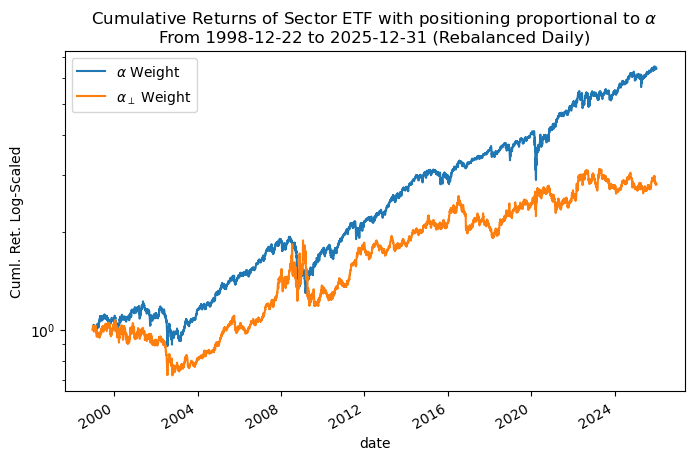

In [37]:
(df_ports
    .rename(columns = {"variable": ""})
    .pivot(index = "date", columns = "", values = "weighted_rtn")
    .apply(lambda x: np.cumprod(1 + x))
    .rename(columns = renamer)
    .plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of Sector ETF with positioning proportional to $\alpha$" + "\nFrom {} to {} (Rebalanced Daily)".format(
            df_ports.date.min().date(),
            df_ports.date.max().date())))

plt.show()

The sharpes of the portfolio

In [38]:
(df_ports
    .drop(columns = ["date"])
    .groupby(["variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .T
    .reset_index(drop = True)
    .rename(columns = renamer))

variable,$\alpha$ Weight,$\alpha_{\perp}$ Weight
0,0.61112,0.322962


When the weighting of the portfolio $\mathbf{w} = \mathbf{\alpha_{\perp}}/\lVert \mathbf{\alpha_{\perp}} \rVert$ leads to the following returns 
\begin{align}
\mathbf{w}^\top\mathbf{r}_t &= \left(\frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}\right)^\top \mathbf{r_t}\\
                            &= \left(\frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}\right)^\top (\mathbf{\alpha} + \mathbf{B}f_t + \epsilon_t) \\
                            &=
\underbrace{
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{\alpha_{\parallel}}}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
    +
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{\alpha_{\perp}}}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
}_{\alpha = \alpha_{\perp} + \alpha_{\parallel},\;\;\alpha_{\perp}\top\alpha_{\parallel} = 0}
+
\underbrace{
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{B}f_t}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
}_{0 \; \text{orthogonal}}
+
\frac{\mathbf{\alpha_{\perp}}^\top \epsilon_t}
{\lVert \mathbf{\alpha_{\perp}} \rVert}\\
&= \lVert \alpha_{\perp} \rVert + \frac{\alpha_{\perp}^\top\epsilon_t}{\lVert \alpha_{\perp} \rVert}
\end{align}

That leads to some nice first and second moments which can be used to help describe the sharpe. 

\begin{align}
\mathbb{E}(\mathbf{w}^\top\mathbf{r_t}) &= \lVert \alpha_{\perp} \rVert \\
Var(\mathbf{w}^\top\mathbf{r_t}) &= \frac{\alpha_{\perp}^\top \Omega_{\epsilon} \alpha_{\perp}}{\lVert \alpha_{\perp} \rVert^2}
\end{align}

In [39]:
omega_epsilon = (pd
    .concat(resids, axis = 1)
    .cov())

In [40]:
alpha_perp = (df_weight
    .set_index("ticker")
    .alpha_perp)

These have interseting properties when applying them to sharpe ratios. 
\begin{align}
SR = \lVert \alpha_{\perp} \rVert \cdot \sqrt{\frac{\lVert \alpha_{\perp} \rVert^2}{\alpha_{\perp}^\top \Omega_{\epsilon} \alpha_{\perp}}}
\end{align}
Using the upper bound of via the operator norm
\begin{align} 
\frac{\alpha_{\perp}^\top \Omega_{\epsilon} \alpha_{\perp}}{\lVert \alpha_{\perp} \rVert^2} \leq \lVert \Omega_{\epsilon} \rVert \rightarrow SR \geq \frac{\lVert \alpha_{\perp} \rVert}{\sqrt{\lVert \Omega_{\epsilon} \rVert}}
\end{align}

In [41]:
expected_rtn = np.linalg.norm(alpha_perp)
variance     = (alpha_perp @ omega_epsilon @ alpha_perp) / (expected_rtn ** 2)

In [66]:
(df_ports
    .drop(columns = ["date"])
    .groupby("variable")
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .T
    .assign(exp_sharpe = lambda x: expected_rtn / variance)
    .reset_index(drop = True)
    .rename(columns = renamer)
    .rename(columns = {"exp_sharpe": "Exp. Sharpe"}))

variable,$\alpha$ Weight,$\alpha_{\perp}$ Weight,Exp. Sharpe
0,0.61112,0.322962,2.123442


In [45]:
w = alpha_perp / np.linalg.norm(alpha_perp)
B.T @ w

array([-1.72400235e-16,  6.62081856e-17])

In [86]:
# Custom annotation function
def annotate_diagonal(data, mask, ax):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if mask[i, j]:
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f'{data[i, j]:.2e}',
                    ha='center',
                    va='center',
                    color='black'
                )

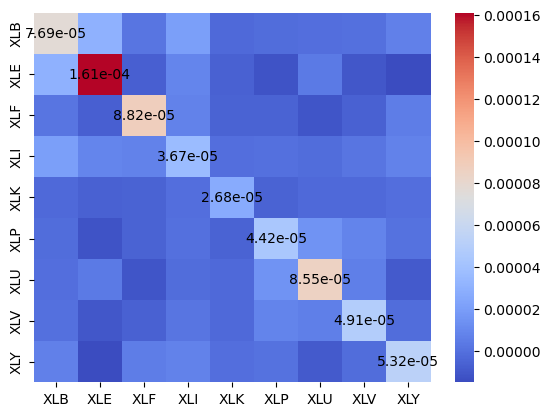

In [87]:
ax   = sns.heatmap(omega_epsilon, annot=False, cmap='coolwarm')
mask = np.zeros_like(omega_epsilon, dtype=bool)
np.fill_diagonal(mask, True)


annotate_diagonal(omega_epsilon.values, mask, ax)

plt.show()